SVM & Logistic Regression for Wine-Quality Prediction

# Import libraries

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from scipy.spatial.distance import cdist

# Load datasets

In [64]:
red = pd.read_csv("/Users/ettoreoteri/Desktop/wine+quality/winequality-red.csv", sep=";")
white = pd.read_csv("/Users/ettoreoteri/Desktop/wine+quality/winequality-white.csv", sep=";")
red["type"] = 0; white["type"] = 1
data = pd.concat([red, white], axis=0).reset_index(drop=True)

# Data Exploration

=== Descriptive statistics ===
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.00900

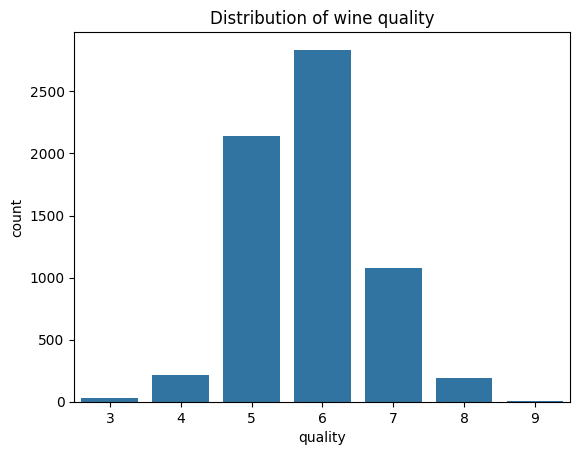

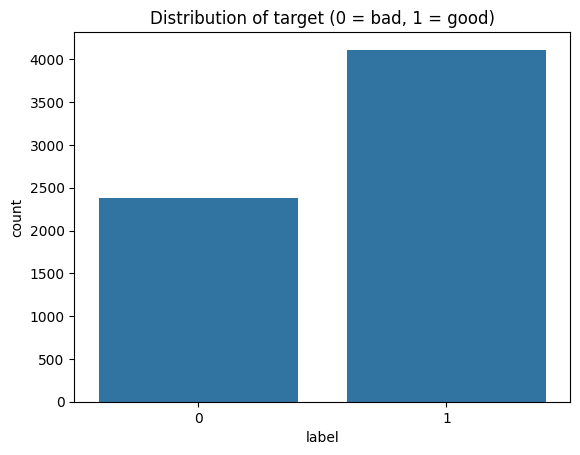

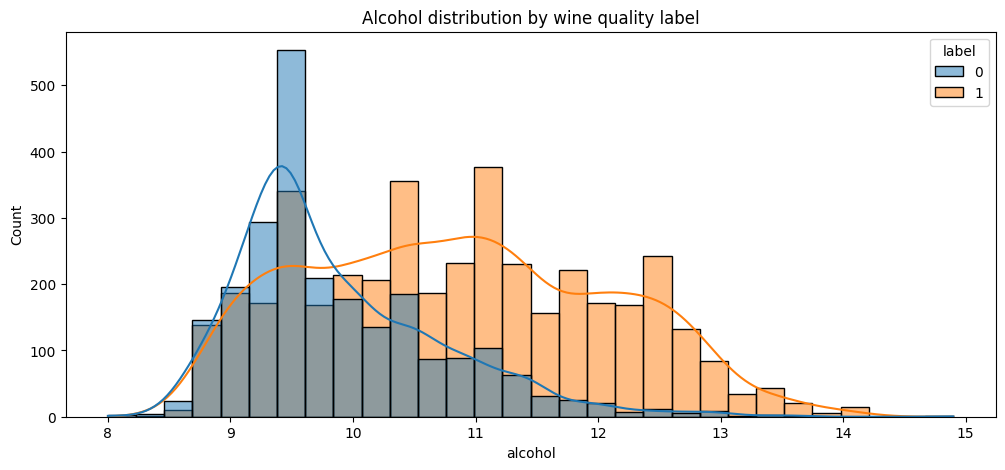

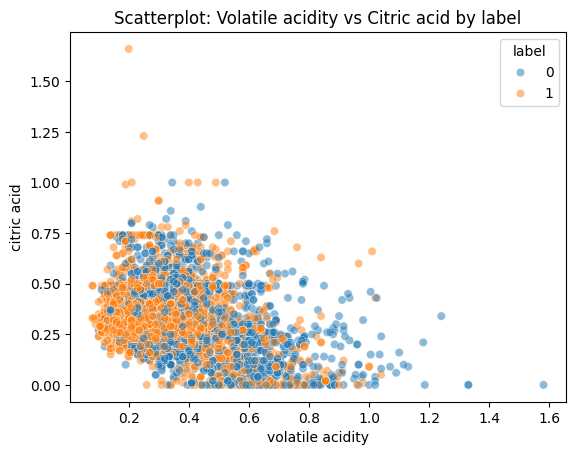

In [65]:
print("=== Descriptive statistics ===")
print(data.describe())

sns.countplot(x="quality", data=data)
plt.title("Distribution of wine quality")
plt.show()

data["label"] = (data["quality"] >= 6).astype(int)
sns.countplot(x="label", data=data)
plt.title("Distribution of target (0 = bad, 1 = good)")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(data=data, x="alcohol", hue="label", kde=True, bins=30)
plt.title("Alcohol distribution by wine quality label")
plt.show()

sns.scatterplot(x="volatile acidity", y="citric acid", hue="label", data=data, alpha=0.5)
plt.title("Scatterplot: Volatile acidity vs Citric acid by label")
plt.show()

# Preprocessing

In [66]:
X = data.drop(["quality", "label"], axis=1).values
y = data["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

mean, std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Logistic Regression

In [67]:
class LogisticRegression:
    def __init__(self, lr=0.01, n_iters=300, reg_lambda=0.01):
        self.lr, self.n_iters, self.reg_lambda = lr, n_iters, reg_lambda

    def stable_sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0
        self.losses = []
        self.train_acc = []

        for _ in range(self.n_iters):
            linear = X @ self.w + self.b
            pred = self.stable_sigmoid(linear)
            dw = X.T @ (pred - y) / n + self.reg_lambda * self.w
            db = (pred - y).mean()
            self.w -= self.lr * dw
            self.b -= self.lr * db
            loss = -np.mean(y * np.log(pred + 1e-9) + (1 - y) * np.log(1 - pred + 1e-9))
            self.losses.append(loss)
            self.train_acc.append(accuracy_score(y, (pred >= 0.5).astype(int)))

    def predict(self, X):
        return (self.stable_sigmoid(X @ self.w + self.b) >= 0.5).astype(int)

# Linear SVM

In [68]:
class SVM:
    def __init__(self, lr=0.001, lam=0.01, n_iters=300):
        self.lr = lr
        self.lam = lam
        self.n_iters = n_iters
        self.losses = []      
        self.train_acc = []   

    def fit(self, X, y):
        n,d = X.shape
        y_ = np.where(y==1,1,-1)
        self.w = np.zeros(d)
        self.b = 0

        for _ in range(self.n_iters):
            loss = 0
            for i,x in enumerate(X):
                cond = y_[i]*(x@self.w - self.b) >= 1
                if cond:
                    self.w -= self.lr*(2*self.lam*self.w)
                else:
                    self.w -= self.lr*(2*self.lam*self.w - y_[i]*x)
                    self.b -= self.lr*y_[i]
                loss += max(0,1-y_[i]*(x@self.w-self.b))
            self.losses.append(loss/n)  
            
            y_pred_train = self.predict(X)
            self.train_acc.append(np.mean(y_pred_train == y))

    def predict(self, X):
        return ((X@self.w - self.b) >= 0).astype(int)

# RBF Kernel

In [69]:
def rbf_kernel_matrix(X1, X2, gamma=0.5):
    dists = cdist(X1, X2, 'sqeuclidean')
    return np.exp(-gamma * dists)

# Kernel Logistic Regression

In [70]:
class KernelLogisticRegression:
    def __init__(self, kernel=rbf_kernel_matrix, lr=0.001, n_iters=150, gamma=0.5):
        self.kernel, self.lr, self.n_iters, self.gamma = kernel, lr, n_iters, gamma

    def stable_sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.X = X
        self.y = y
        n = len(y)
        self.alpha = np.zeros(n)
        self.losses = []
        self.train_acc = []

        K = self.kernel(X, X, gamma=self.gamma)
        for _ in range(self.n_iters):
            z = self.alpha @ K
            pred = self.stable_sigmoid(z)
            grad = pred - y
            self.alpha -= self.lr * grad
            loss = -np.mean(y * np.log(pred + 1e-9) + (1 - y) * np.log(1 - pred + 1e-9))
            self.losses.append(loss)
            self.train_acc.append(accuracy_score(y, (pred >= 0.5).astype(int)))

    def predict(self, Z):
        K_test = self.kernel(Z, self.X, gamma=self.gamma)
        pred = self.stable_sigmoid(self.alpha @ K_test.T)
        return (pred >= 0.5).astype(int)


# Kernel SVM

In [71]:
class KernelSVM:
    def __init__(self,kernel=rbf_kernel_matrix,lr=0.001,n_iters=150,gamma=0.5):
        self.kernel = kernel
        self.lr = lr
        self.n_iters = n_iters
        self.gamma = gamma
        self.alpha = None
        self.losses = []      
        self.train_acc = []   

    def fit(self,X,y):
        self.X = X
        self.y = np.where(y==1,1,-1)
        n = len(y)
        self.alpha = np.zeros(n)
        K = self.kernel(X,X,gamma=self.gamma)

        for _ in range(self.n_iters):
            for i in range(n):
                cond = self.y[i]*(self.alpha*self.y)@K[:,i]>=1
                if not cond: self.alpha[i]+=self.lr

            margin = self.y * (K @ (self.alpha * self.y))
            hinge_loss = np.mean(np.maximum(0, 1-margin))
            self.losses.append(hinge_loss)

            y_pred_train = self.predict(X)
            self.train_acc.append(np.mean(y_pred_train == y))

    def predict(self,Z):
        K_test = self.kernel(Z,self.X,gamma=self.gamma)
        pred = (self.alpha*self.y) @ K_test.T
        return (pred >= 0).astype(int)

# Grid Search

In [72]:
def grid_search(model_name, X, y, params):
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    best_f1 = -1
    best_params = None

    for lr in params.get("lr", [0.01]):
        for lam in params.get("lam", [0.01]):
            for gamma in params.get("gamma", [0.5]):
                f1s = []
                for tr, va in kf.split(X):
                    if model_name=="LR":
                        m = LogisticRegressionScratch(lr=lr, reg_lambda=lam, n_iters=200)
                    elif model_name=="SVM":
                        m = SVM(lr=lr, lam=lam, n_iters=300)
                    elif model_name=="KLR":
                        m = KernelLogisticRegression(lr=lr, n_iters=100, gamma=gamma)
                    elif model_name=="KSVM":
                        m = KernelSVM(lr=lr, n_iters=100, gamma=gamma)

                    m.fit(X[tr], y[tr])
                    preds = m.predict(X[va])
                    f1s.append(f1_score(y[va], preds))
                
                avg_f1 = np.mean(f1s)
                if avg_f1 > best_f1:
                    best_f1 = avg_f1
                    best_params = {"lr": lr, "lam": lam, "gamma": gamma}

    print(f"{model_name} Best params: {best_params}, F1={best_f1:.3f}")
    return best_params


# Evaluation with Extra Analysis

In [73]:
def evaluate(model,X_train,y_train,X_test,y_test):
    model.fit(X_train,y_train)
    preds=model.predict(X_test)

    acc_train = accuracy_score(y_train, model.predict(X_train))
    acc_test = accuracy_score(y_test, preds)
    prec=precision_score(y_test,preds)
    rec=recall_score(y_test,preds)
    f1=f1_score(y_test,preds)
    cm=confusion_matrix(y_test,preds)

    print(f"{model.__class__.__name__}: train_acc={acc_train:.3f}, test_acc={acc_test:.3f}, prec={prec:.3f}, rec={rec:.3f}, f1={f1:.3f}")
    print("\nClassification report:\n", classification_report(y_test, preds))

    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
    plt.title(model.__class__.__name__+" Confusion Matrix")
    plt.show()

    if hasattr(model,"losses") and len(model.losses)>0:
        plt.plot(model.losses)
        plt.title(model.__class__.__name__+" Loss")
        plt.show()

    if hasattr(model,"train_acc"):
        plt.plot(model.train_acc, label="Train Acc")
        plt.axhline(y=acc_test, color="red", linestyle="--", label="Final Test Acc")
        plt.legend(); plt.title(model.__class__.__name__+" Training vs Test Accuracy")
        plt.show()

    false_pos = np.where((preds==1)&(y_test==0))[0]
    false_neg = np.where((preds==0)&(y_test==1))[0]
    print(f"False Positives: {len(false_pos)}, False Negatives: {len(false_neg)}")
    print(f"Type I error (FP rate): {len(false_pos)/len(y_test):.3f}")
    print(f"Type II error (FN rate): {len(false_neg)/len(y_test):.3f}")

    if acc_train - acc_test > 0.1:
        print("Possible Overfitting: train accuracy much higher than test.")
    elif acc_train < 0.65 and acc_test < 0.65:
        print("Possible Underfitting: both train and test accuracy are low.")
    else:
        print("Model seems reasonably fit.")

    return preds

# Run Grid Search

In [74]:
best_lr_params = grid_search("LR", X, y, {"lr":[0.01,0.05], "lam":[0.001,0.01]})
best_svm_params = grid_search("SVM", X, y, {"lr":[0.001,0.005], "lam":[0.001,0.01]})
best_klr_params = grid_search("KLR", X, y, {"lr":[0.001,0.01], "gamma":[0.1,0.5]})
best_ksvm_params = grid_search("KSVM", X, y, {"lr":[0.001,0.005], "gamma":[0.1,0.5]})

LR Best params: {'lr': 0.05, 'lam': 0.01, 'gamma': 0.5}, F1=0.775
SVM Best params: {'lr': 0.001, 'lam': 0.01, 'gamma': 0.5}, F1=0.770
KLR Best params: {'lr': 0.01, 'lam': 0.01, 'gamma': 0.5}, F1=0.789
KSVM Best params: {'lr': 0.005, 'lam': 0.01, 'gamma': 0.5}, F1=0.787


# Evaluate models with the best parameters

LogisticRegression: train_acc=0.734, test_acc=0.725, prec=0.752, rec=0.843, f1=0.795

Classification report:
               precision    recall  f1-score   support

           0       0.66      0.52      0.58       477
           1       0.75      0.84      0.79       823

    accuracy                           0.72      1300
   macro avg       0.70      0.68      0.69      1300
weighted avg       0.72      0.72      0.72      1300



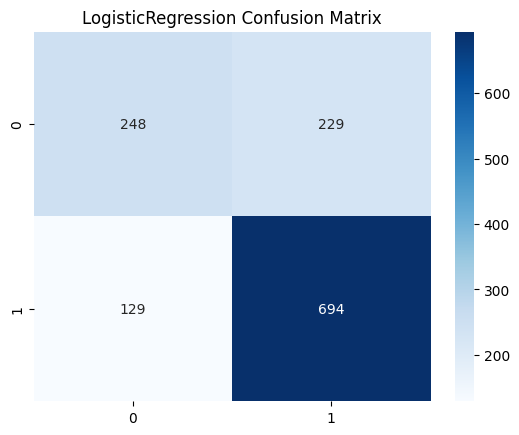

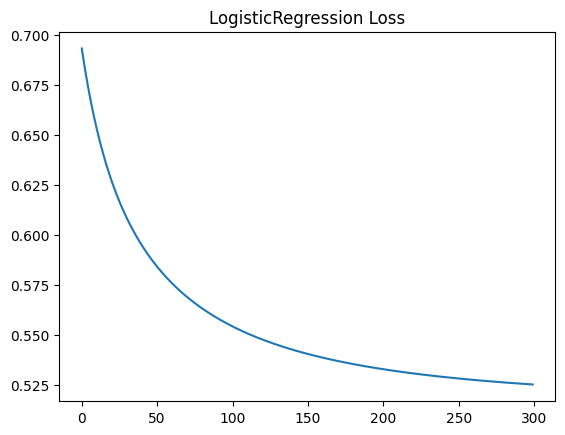

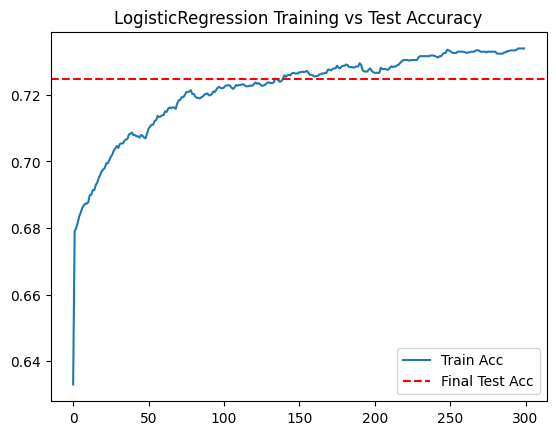

False Positives: 229, False Negatives: 129
Type I error (FP rate): 0.176
Type II error (FN rate): 0.099
Model seems reasonably fit.
SVM: train_acc=0.750, test_acc=0.733, prec=0.759, rec=0.848, f1=0.801

Classification report:
               precision    recall  f1-score   support

           0       0.67      0.53      0.60       477
           1       0.76      0.85      0.80       823

    accuracy                           0.73      1300
   macro avg       0.71      0.69      0.70      1300
weighted avg       0.73      0.73      0.73      1300



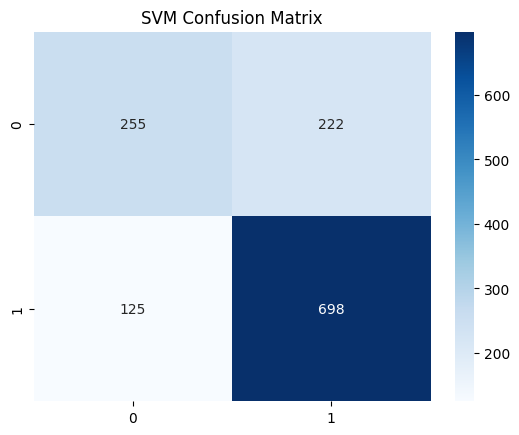

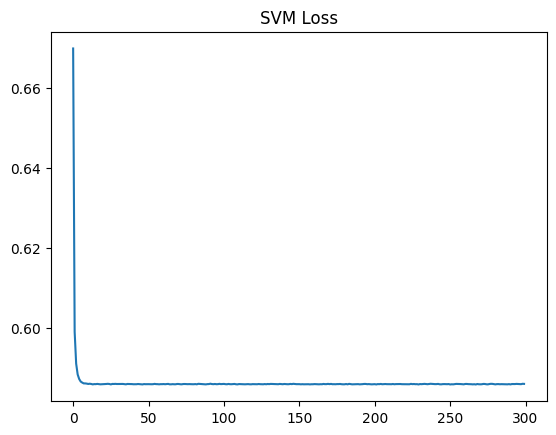

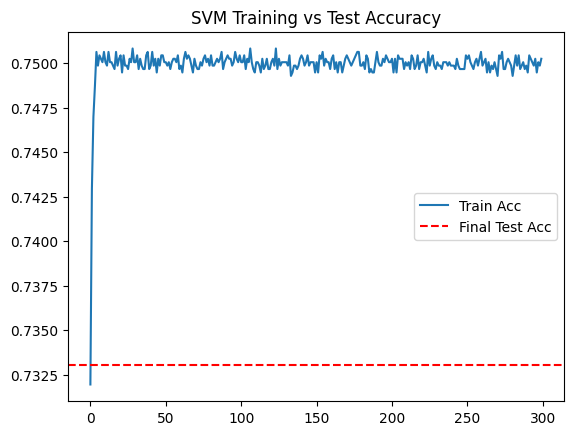

False Positives: 222, False Negatives: 125
Type I error (FP rate): 0.171
Type II error (FN rate): 0.096
Model seems reasonably fit.
KernelLogisticRegression: train_acc=0.877, test_acc=0.797, prec=0.822, rec=0.866, f1=0.844

Classification report:
               precision    recall  f1-score   support

           0       0.75      0.68      0.71       477
           1       0.82      0.87      0.84       823

    accuracy                           0.80      1300
   macro avg       0.78      0.77      0.78      1300
weighted avg       0.79      0.80      0.79      1300



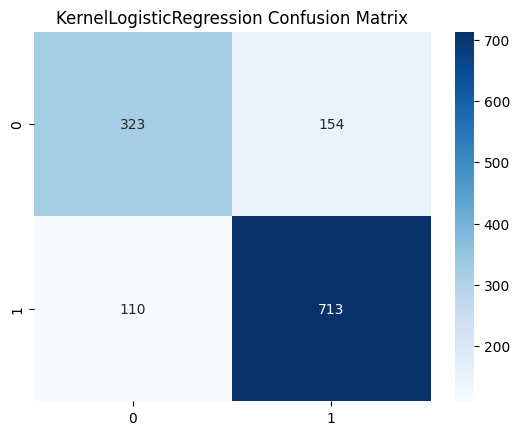

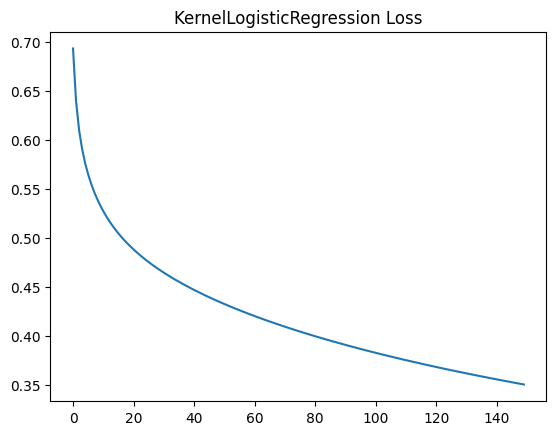

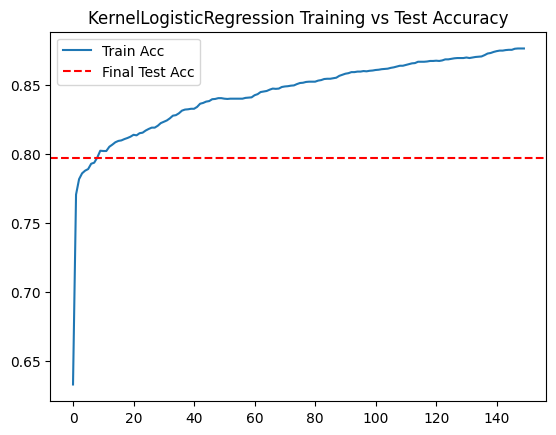

False Positives: 154, False Negatives: 110
Type I error (FP rate): 0.118
Type II error (FN rate): 0.085
Model seems reasonably fit.
KernelSVM: train_acc=0.873, test_acc=0.803, prec=0.819, rec=0.885, f1=0.850

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.66      0.71       477
           1       0.82      0.88      0.85       823

    accuracy                           0.80      1300
   macro avg       0.79      0.77      0.78      1300
weighted avg       0.80      0.80      0.80      1300



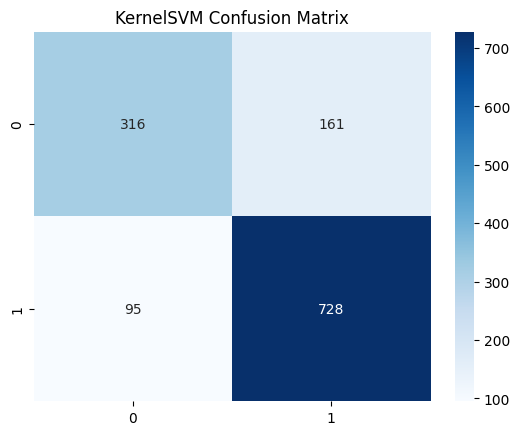

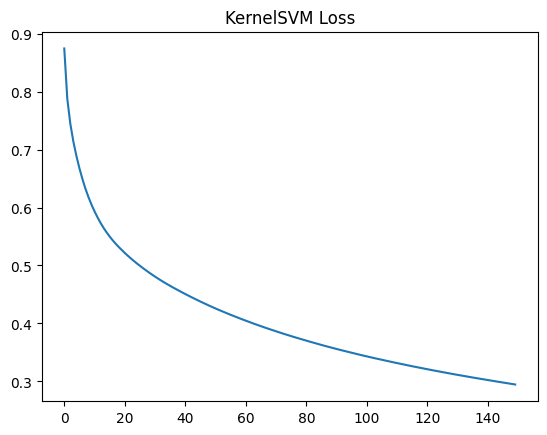

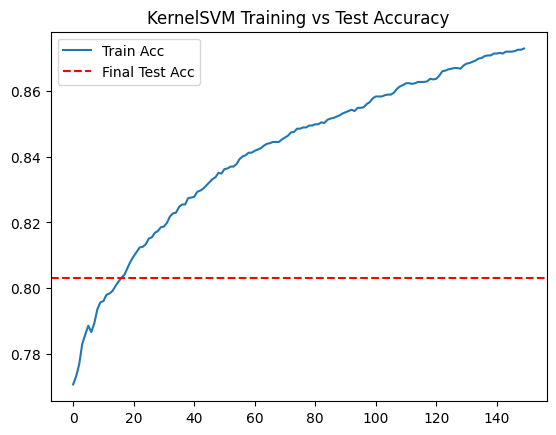

False Positives: 161, False Negatives: 95
Type I error (FP rate): 0.124
Type II error (FN rate): 0.073
Model seems reasonably fit.


In [75]:
evaluate(LogisticRegression(lr=best_lr_params['lr'], reg_lambda=best_lr_params['lam']),
         X_train,y_train,X_test,y_test) ;
evaluate(SVM(lr=best_svm_params['lr'], lam=best_svm_params['lam']),
         X_train,y_train,X_test,y_test) ;
evaluate(KernelLogisticRegression(lr=best_klr_params['lr'], gamma=best_klr_params['gamma']),
         X_train,y_train,X_test,y_test) ;
evaluate(KernelSVM(lr=best_ksvm_params['lr'], gamma=best_ksvm_params['gamma']),
         X_train,y_train,X_test,y_test) ;